Could not load dataset from URL. Generating synthetic Advertising dataset...

Dataset Overview:
           TV      Radio  Newspaper      Sales
0  118.616634  33.891424  11.209263  14.698865
1  285.707149   8.786298  90.352738  17.700810
2  222.278243  12.273292  51.019985  16.306268
3  183.610960  45.434938  82.819289  19.302015
4   55.245406  32.289308  32.684911  11.631069

--- DATA INSPECTION ---
Dataset Shape: (200, 4)

Null Values Count:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Descriptive Statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   150.361808   27.696881   52.546606   15.925208
std     85.518515   13.185054   30.423571    4.629575
min     11.601414    5.227771    2.072927    3.680840
25%     76.288900   16.765813   26.296511   11.993082
50%    153.401013   29.373795   53.014548   16.162355
75%    229.489289   38.398969   81.300374   19.542524
max    296.197212   49.

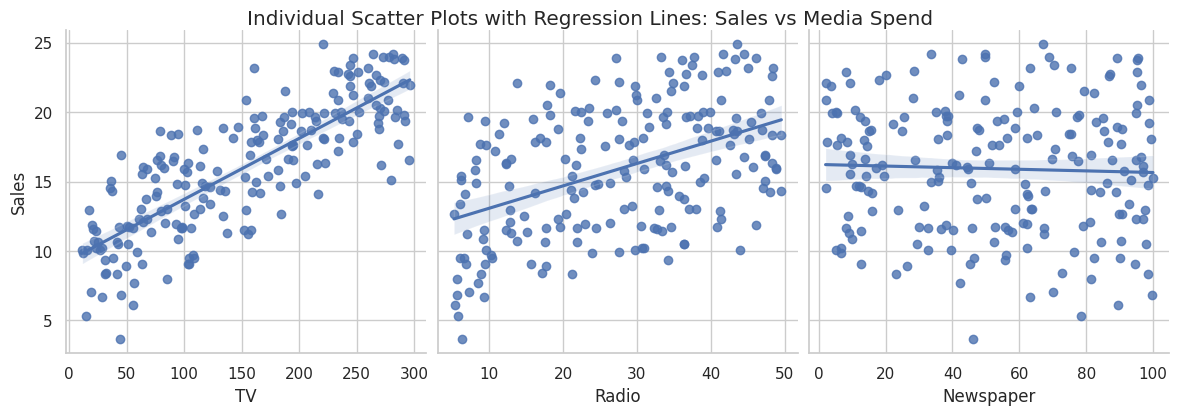

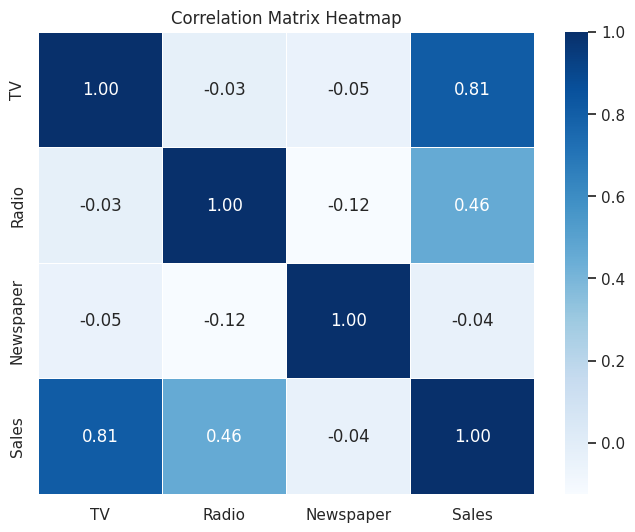


Training set size: 160 samples
Testing set size: 40 samples

--- MODEL PERFORMANCE EVALUATION ---
                  Model      MAE     RMSE  R2 Score
      Linear Regression 1.057304 1.246367  0.926814
Random Forest Regressor 1.302402 1.647415  0.872138

Best Performing Model: Linear Regression


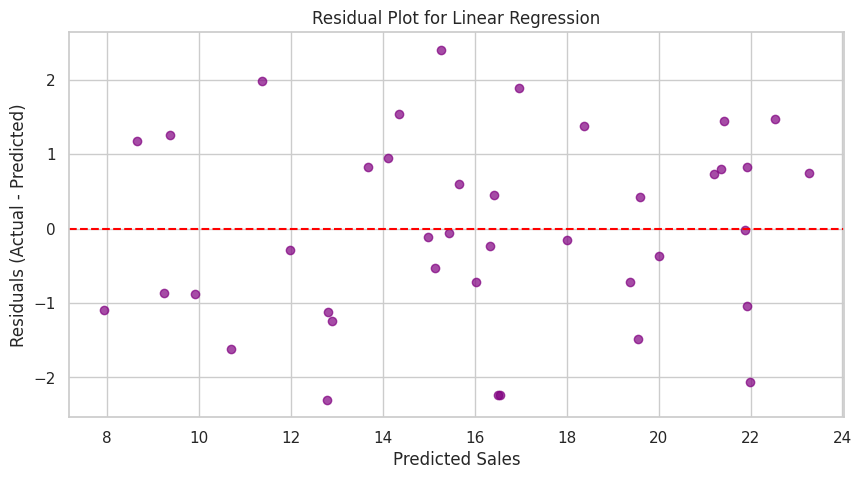


--- ADVERTISING CHANNEL IMPACT INTERPRETATION ---
Linear Regression Coefficients:
  Channel  Linear_Coeff
       TV      0.044262
    Radio      0.173428
Newspaper      0.010772


/tmp/ipykernel_5065/335361911.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Channel', data=rf_importance, palette='viridis')


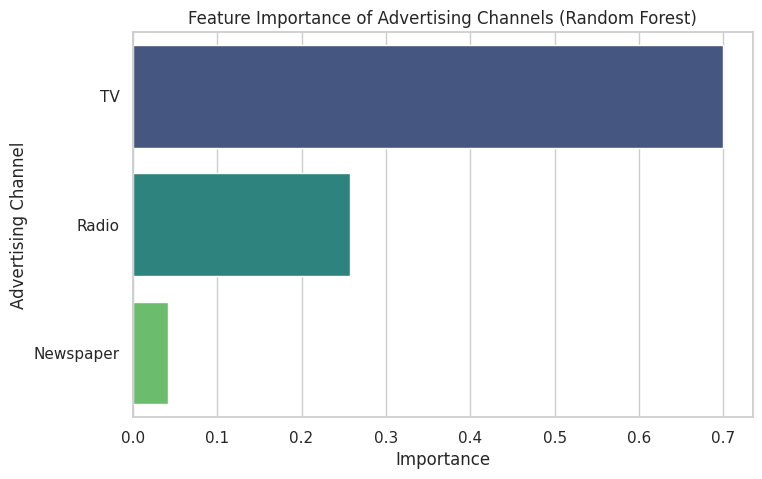


Conclusion: The 'TV' advertising channel has the highest impact on product sales.


In [1]:
# ==============================================================================
# DATA SCIENCE TRACK - TASK 5: SALES PREDICTION USING PYTHON
# Platform: Google Colab
# ==============================================================================

# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==============================================================================
# Step 2: Data Loading / Generation
# ==============================================================================
# Check if the classic Advertising dataset is available locally;
# if not, download or generate synthetic data matching the structure.
try:
    # URL to the classic Advertising dataset
    url = "https://raw.githubusercontent.com/SelvaPrabhakaran/datasets/master/Advertising.csv"
    df = pd.read_csv(url)
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    print("Dataset loaded successfully from URL!\n")
except Exception as e:
    print("Could not load dataset from URL. Generating synthetic Advertising dataset...\n")
    np.random.seed(42)
    n_samples = 200
    tv = np.random.uniform(10, 300, n_samples)
    radio = np.random.uniform(5, 50, n_samples)
    newspaper = np.random.uniform(1, 100, n_samples)
    # Sales generated with noise
    sales = 4.0 + 0.045 * tv + 0.18 * radio + 0.005 * newspaper + np.random.normal(0, 1.5, n_samples)
    df = pd.DataFrame({'TV': tv, 'Radio': radio, 'Newspaper': newspaper, 'Sales': sales})

# Display first few rows
print("Dataset Overview:")
print(df.head())

# ==============================================================================
# Step 3: Exploratory Data Analysis (EDA)
# ==============================================================================
print("\n--- DATA INSPECTION ---")
print(f"Dataset Shape: {df.shape}")
print("\nNull Values Count:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

# Pairplot of all features
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='reg')
plt.suptitle('Individual Scatter Plots with Regression Lines: Sales vs Media Spend', y=1.02)
plt.show()

# Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# ==============================================================================
# Step 4: Train / Test Split
# ==============================================================================
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# ==============================================================================
# Step 5: Model Training
# ==============================================================================
# 1. Baseline Model: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Additional Model: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# ==============================================================================
# Step 6: Model Evaluation (MAE, RMSE, R² Score)
# ==============================================================================
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}

results = pd.DataFrame([
    evaluate_model(y_test, y_pred_lr, 'Linear Regression'),
    evaluate_model(y_test, y_pred_rf, 'Random Forest Regressor')
])

print("\n--- MODEL PERFORMANCE EVALUATION ---")
print(results.to_string(index=False))

# Select the best performing model based on R2 Score
best_model_name = results.loc[results['R2 Score'].idxmax()]['Model']
best_preds = y_pred_rf if best_model_name == 'Random Forest Regressor' else y_pred_lr
print(f"\nBest Performing Model: {best_model_name}")

# ==============================================================================
# Step 7: Residual Analysis for the Best Model
# ==============================================================================
residuals = y_test - best_preds

plt.figure(figsize=(10, 5))
plt.scatter(best_preds, residuals, color='purple', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title(f'Residual Plot for {best_model_name}')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# ==============================================================================
# Step 8: Interpretation & Feature Importance
# ==============================================================================
print("\n--- ADVERTISING CHANNEL IMPACT INTERPRETATION ---")

# Linear Regression Coefficients
coeff_df = pd.DataFrame({'Channel': X.columns, 'Linear_Coeff': lr_model.coef_})
print("Linear Regression Coefficients:")
print(coeff_df.to_string(index=False))

# Random Forest Feature Importances
rf_importance = pd.DataFrame({'Channel': X.columns, 'Importance': rf_model.feature_importances_})
rf_importance = rf_importance.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Channel', data=rf_importance, palette='viridis')
plt.title('Feature Importance of Advertising Channels (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Advertising Channel')
plt.show()

# Summary Conclusion
highest_impact_channel = rf_importance.iloc[0]['Channel']
print(f"\nConclusion: The '{highest_impact_channel}' advertising channel has the highest impact on product sales.")